In [11]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Positional Encoding: 
# Self-Attention에 없는 Sequence Order를 추가

class PositionalEncoding(nn.Module):
    
    def __init__(
        self,
        num_hiddens: int, # D
        dropout: float,
        max_len: int = 1000,
    ) -> None:
        super().__init__()
        
        if num_hiddens % 2 != 0:
            raise ValueError(
                "num_hiddens must be even."
            )
            
        self.dropout = nn.Dropout(
            p=dropout,
        )
        
        # [1, max_len, D]
        self.P: torch.Tensor = torch.zeros(
            (
                1,
                max_len,
                num_hiddens,
            )
        )
        
        # Position Index:
        # [max_len] -> [max_len, 1]
        positions = torch.arange(
            max_len,
            dtype=torch.float32,
        ).reshape(
            -1,
            1,
        )
        
        # 각 Sine/Cosine pair가 사용할 frequency scale
        # [D / 2]
        frequency_scales = torch.pow(
            10000,
            torch.arange(
                0,
                num_hiddens,
                2,
                dtype=torch.float32,
            )
            / num_hiddens,
        )

        # Broadcasting:
        # [max_len, 1] / [D / 2]
        # → [max_len, D / 2]
        angles = (
            positions
            / frequency_scales
        )

        # Even Dimension에는 Sine을 저장한다.
        self.P[:, :, 0::2] = torch.sin(
            angles
        )

        # Odd Dimension에는 Cosine을 저장한다.
        self.P[:, :, 1::2] = torch.cos(
            angles
        )


    def forward(
        self,
        X: torch.Tensor, # X: [B, T, D]
    ) -> torch.Tensor:
        
        # [1, max_len, D] -> [1, T, D]
        positional_values = self.P[
            :,
            X.shape[1],
            :,
        ].to(
            device=X.device,
            dtype=X.dtype,
        )
        
        # Token Embedding X: [B, T, D]
        # 위치별 고유 신호  P: [1, T, D]
        # 위치 정보를 포함한 Token X + P: [B, T, D]
        return self.dropout(
            X + positional_values
        )

Encoded output: (1, 60, 32)
Positional encoding: (1, 60, 32)


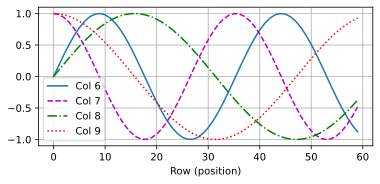

In [13]:
# Positional Encoding Frequency 확인

encoding_dim = 32
num_steps = 60

positional_encoding = PositionalEncoding(
    num_hiddens=encoding_dim,
    dropout=0.0,
)


# Token Embedding이 모두 0이므로
# Output에는 Positional Encoding만 남는다.
X = positional_encoding(
    torch.zeros(
        (
            1,
            num_steps,
            encoding_dim,
        )
    )
)

# [1, 60, 32]
P = positional_encoding.P[
    :,
    :X.shape[1],
    :,
]


print(
    "Encoded output:",
    tuple(X.shape),
)

print(
    "Positional encoding:",
    tuple(P.shape),
)


d2l.check_shape(
    X,
    (
        1,
        num_steps,
        encoding_dim,
    ),
)


# Column 6, 7은 같은 frequency의 Sine/Cosine pair다.
# Column 8, 9는 그보다 낮은 frequency의 pair다.
d2l.plot(
    torch.arange(num_steps),
    P[0, :, 6:10].T,
    xlabel="Row (position)",
    figsize=(6, 2.5),
    legend=[
        f"Col {dimension}"
        for dimension in range(6, 10)
    ],
)

In [14]:
# Binary Frequency 비교:
# 가장 오른쪽 bit는 매 position마다 바뀌고, 왼쪽으로 갈수록 더 느리게 바뀐다.

for position in range(8):
    print(
        f"{position} in binary is "
        f"{position:>03b}"
    )

0 in binary is 000
1 in binary is 001
2 in binary is 010
3 in binary is 011
4 in binary is 100
5 in binary is 101
6 in binary is 110
7 in binary is 111


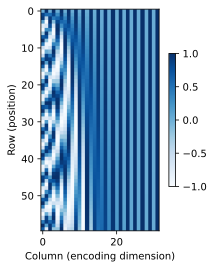

In [15]:
# 전체 Positional Encoding Heatmap:
# Heatmap에서 왼쪽 Dimension은 빠르게 변하고, 
# 오른쪽 Dimension으로 갈수록 더 천천히 변하는 pattern을 확인

# P: [1, T, D]
#
# Heatmap input:
# [B, Head, Position, Encoding Dimension]
# [1, 1, 60, 32]
positional_heatmap = (
    P[0, :, :]
    .unsqueeze(0)
    .unsqueeze(0)
)


d2l.show_heatmaps(
    positional_heatmap,
    xlabel="Column (encoding dimension)",
    ylabel="Row (position)",
    figsize=(3.5, 4),
    cmap="Blues",
)

In [16]:
# Relative Position Projection 검증

position = 7
offset = 3
pair_index = 4


# ω_j = 1 / 10000^(2j/d)
omega = 1 / (
    10000
    ** (
        2 * pair_index
        / encoding_dim
    )
)

angle = torch.tensor(
    offset * omega,
    dtype=P.dtype,
)

cos_angle = torch.cos(
    angle
)

sin_angle = torch.sin(
    angle
)


# Offset δ에 해당하는 2 × 2 Linear Projection
projection = torch.stack([
    torch.stack([
        cos_angle,
        sin_angle,
    ]),
    torch.stack([
        -sin_angle,
        cos_angle,
    ]),
])


# Position i의 Sine/Cosine pair
current_pair = P[
    0,
    position,
    2 * pair_index:2 * pair_index + 2,
]


# Projection을 사용해 Position i + δ를 계산
projected_pair = (
    projection
    @ current_pair
)


# P에서 직접 가져온 Position i + δ의 실제 값
target_pair = P[
    0,
    position + offset,
    2 * pair_index:2 * pair_index + 2,
]


print(
    "Current position:",
    position,
)

print(
    "Target position:",
    position + offset,
)

print(
    "Current pair:",
    current_pair,
)

print(
    "Projected pair:",
    projected_pair,
)

print(
    "Actual target pair:",
    target_pair,
)


torch.testing.assert_close(
    projected_pair,
    target_pair,
    atol=1e-6,
    rtol=1e-6,
)

Current position: 7
Target position: 10
Current pair: tensor([0.6442, 0.7648])
Projected pair: tensor([0.8415, 0.5403])
Actual target pair: tensor([0.8415, 0.5403])
